# Lecture 1 Notebook: Data Replication and Numerical Implementation

**Macroeconomics B - Chapter 15**

This notebook lines up with the slides in two places:

1. **Notebook Part 1:** replicate the Denmark figure and compute a few descriptive statistics.
2. **Notebook Part 2:** implement the pricing equations in simple code.
2. **Notebook Part 3:** Tobin's q and the optimal level of investment.


Note that you require an API key from FRED to run Part 1.
You can get a FRED API key by creating or logging into a FRED account and then requesting one at [fredaccount.stlouisfed.org](https://fredaccount.stlouisfed.org/apikey).

In [12]:
from pathlib import Path
import io

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from statsmodels.tsa.filters.hp_filter import hpfilter

# If you keep the notebook in another folder, change this path.
# This is the main line you should edit when you want to save the figure somewhere else.
LECTURE_DIR = Path.cwd()

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["font.size"] = 12

## Notebook Part 1: Replicate the Denmark Figure

We download the Danish data, compute the output gap, reproduce the figure, and then compute a few simple descriptive statistics.


In [ ]:
# You use the FRED API key here to download the Denmark data. 
# Log into your FRED account to get your own API key if you don't have one. You can also use the same API key as in the lecture, but it is better to have your own key in case the one in the lecture gets blocked for some reason.
api_key = "9fb7818ec505ebe0f36e58efc607471c"
base_url = "https://api.stlouisfed.org/fred/series/observations"

gdp_params = {
    "series_id": "CLVMNACSCAB1GQDK",
    "api_key": api_key,
    "file_type": "json",
}
house_params = {
    "series_id": "QDKR368BIS",
    "api_key": api_key,
    "file_type": "json",
}

# You download one series for real GDP and one for house price growth.
gdp_response = requests.get(base_url, params=gdp_params, timeout=30)  # timeout means that the request will fail if it takes more than 30 seconds
house_response = requests.get(base_url, params=house_params, timeout=30)
gdp_response.raise_for_status() # raise_for_status() will raise an error if the request was not successful)
house_response.raise_for_status()

# You turn the downloaded JSON data into pandas DataFrames.
gdp = pd.DataFrame(gdp_response.json()["observations"])[["date", "value"]] 
house = pd.DataFrame(house_response.json()["observations"])[["date", "value"]]

gdp.columns = ["date", "CLVMNACSCAB1GQDK"]
house.columns = ["date", "QDKR368BIS"]

# You convert dates and values into formats that pandas can work with.
gdp["date"] = pd.to_datetime(gdp["date"], errors="coerce")
house["date"] = pd.to_datetime(house["date"], errors="coerce")
gdp["CLVMNACSCAB1GQDK"] = pd.to_numeric(gdp["CLVMNACSCAB1GQDK"], errors="coerce")
house["QDKR368BIS"] = pd.to_numeric(house["QDKR368BIS"], errors="coerce")

# You drop missing observations and use the date as the index.
gdp = gdp.dropna(subset=["date", "CLVMNACSCAB1GQDK"]).set_index("date")
house = house.dropna(subset=["date", "QDKR368BIS"]).set_index("date")

# You combine the two series and keep the sample from 2000 onward.
denmark_data = pd.concat([gdp[["CLVMNACSCAB1GQDK"]], house[["QDKR368BIS"]]], axis=1).dropna()
denmark_data = denmark_data.loc[denmark_data.index >= "2000-01-01"].copy()

# You use the HP filter to split GDP into trend and cycle.
# The cycle is the output gap, measured here in percent of trend GDP.
cycle, trend = hpfilter(np.log(denmark_data["CLVMNACSCAB1GQDK"]), lamb=1600)
denmark_data["output_gap"] = 100 * cycle
denmark_data["house_price_yoy"] = denmark_data["QDKR368BIS"]

# You inspect the most recent observations before plotting.
denmark_data[["output_gap", "house_price_yoy"]].tail()

,output_gap,house_price_yoy
date,,
2024-07-01,0.245496,3.9205
2024-10-01,0.813134,1.9668
2025-01-01,-0.621301,6.9684
2025-04-01,0.155845,5.6281
2025-07-01,1.877309,3.6603


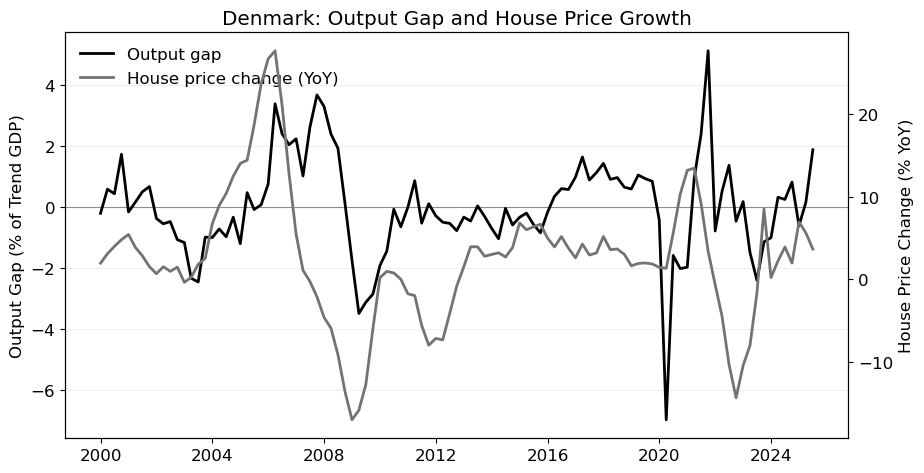

Figure saved to: c:\Users\jfn232\Dropbox\CPH\01_Teaching\MacroB\01_MacroB_summer_term26\Lecture_Material\lecture_01_ch15\figs\denmark_outputgap_houseprice_growth.png


In [14]:
# If you want to save the figure in another place, change the path here.
slide_figure_path = LECTURE_DIR / "figs" / "denmark_outputgap_houseprice_growth.png"

# You create the same two-axis figure that appears in the slides.
fig, ax1 = plt.subplots(figsize=(9.4, 4.9))
line1, = ax1.plot(denmark_data.index, denmark_data["output_gap"], color="black", linewidth=2.0, label="Output gap")
ax1.axhline(0.0, color="black", linewidth=0.8, alpha=0.4)
ax1.set_ylabel("Output Gap (% of Trend GDP)")
ax1.set_xlabel("")
ax1.set_title("Denmark: Output Gap and House Price Growth")
ax1.grid(axis="y", alpha=0.2)

ax2 = ax1.twinx()
line2, = ax2.plot(denmark_data.index, denmark_data["house_price_yoy"], color="0.45", linewidth=2.0, label="House price change (YoY)")
ax2.set_ylabel("House Price Change (% YoY)")

ax1.legend([line1, line2], ["Output gap", "House price change (YoY)"], frameon=False, loc="upper left")
fig.tight_layout()

# You save the figure so you can reuse it in the slide deck.
fig.savefig(slide_figure_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"Figure saved to: {slide_figure_path}")

### Descriptive Statistics

Compute the mean, standard deviation, and correlation for the two Denmark series.

In [ ]:
# You compute the mean and the standard deviation for both series.
summary_stats = denmark_data[["output_gap", "house_price_yoy"]].agg(["mean", "std"]) # agg() applies the functions in the list to each column of the DataFrame
summary_stats 

,output_gap,house_price_yoy
mean,-8.279892e-11,2.566382
std,1.606341e+00,7.879807


In [16]:
# You compute the correlation to see whether the two series move together.
correlation = denmark_data[["output_gap", "house_price_yoy"]].corr()
correlation

,output_gap,house_price_yoy
output_gap,1.000000,0.209636
house_price_yoy,0.209636,1.000000


## Notebook Part 2: Numerical Implementation

### 1. Present Value of Future Payments

From the lecture:

$$PV_t(y_{t+n}) = \frac{y_{t+n}}{(1+r)^n}$$


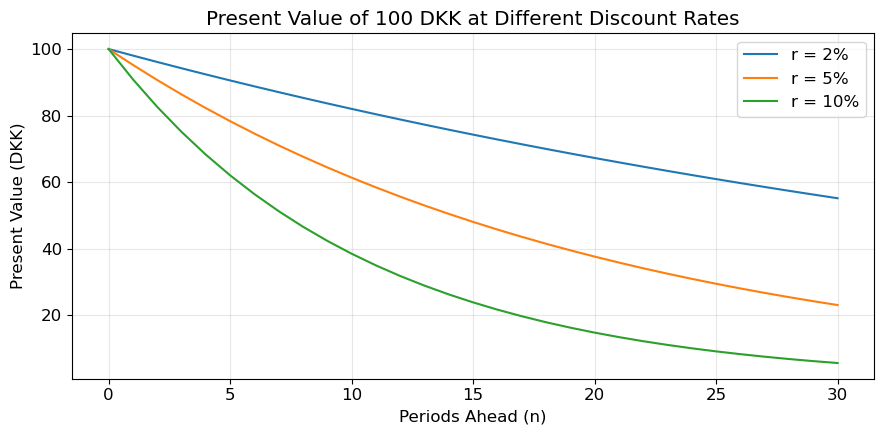

In [ ]:
# You fix one payment and ask how much it is worth today.
payment = 100
periods = np.arange(0, 31) # here we create an array of periods from 0 to 30

fig, ax = plt.subplots()
for r in [0.02, 0.05, 0.10]:
    # You discount the same payment at different interest rates.
    pv = payment / (1 + r) ** periods # we compute the present value for each period
    ax.plot(periods, pv, label=f"r = {r:.0%}") # we plot the present value against the periods for each interest rate

ax.set_xlabel("Periods Ahead (n)")
ax.set_ylabel("Present Value (DKK)")
ax.set_title("Present Value of 100 DKK at Different Discount Rates")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2. Bond Pricing

A one-period zero-coupon bond satisfies

$$P_t^B = \frac{1}{1+r}$$

**Note:** A zero-coupon bond makes no coupon payments and pays its face value, that is, the amount repaid by the bond, only at maturity.

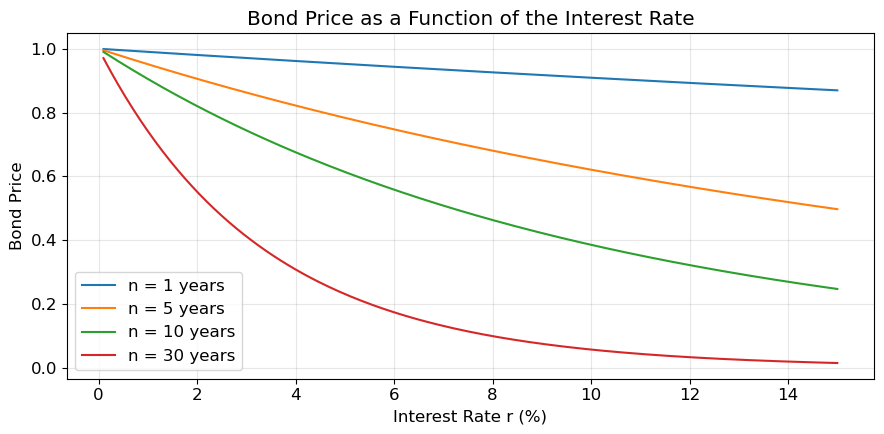

In [ ]:
# You create a grid of interest rates to see how bond prices move.
r_values = np.linspace(0.001, 0.15, 200) # we create an array of interest rates from 0.1% to 15% with 200 points in between

fig, ax = plt.subplots()
for n in [1, 5, 10, 30]:
    # You price bonds with different maturities on the same graph.
    price = 1 / (1 + r_values) ** n
    ax.plot(r_values * 100, price, label=f"n = {n} years")

ax.set_xlabel("Interest Rate r (%)")
ax.set_ylabel("Bond Price")
ax.set_title("Bond Price as a Function of the Interest Rate")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

What we learn from the figure:
- **For a zero-coupon bond, the price falls when the interest rate rises.**
- **Longer-maturity zero-coupon bonds are more interest-sensitive.** Their prices decline more sharply as interest rates increase.
- **Interest rate risk rises with maturity.** Long-term zero-coupon bonds are more volatile than short-term zero-coupon bonds.

### 3. Gordon Growth Model

From the lecture:

$$V_t = \frac{D_t^e}{r + \varepsilon - g}$$

In [ ]:
# You start with one baseline set of Gordon-model numbers.
D_base = 10 # D is the dividend payment
r_base = 0.03 # r is the risk-free interest rate
eps_base = 0.04 # eps is the risk premium, which is the extra return that investors require for holding stocks instead of risk-free bonds
g_base = 0.02 # g is the growth rate of dividends

# You compute the implied stock price from the Gordon formula.
V_base = D_base / (r_base + eps_base - g_base)
print(f"Baseline: D={D_base}, r={r_base}, eps={eps_base}, g={g_base}")
print(f"Stock Price V = {V_base:.1f}")

Baseline: D=10, r=0.03, eps=0.04, g=0.02
Stock Price V = 200.0


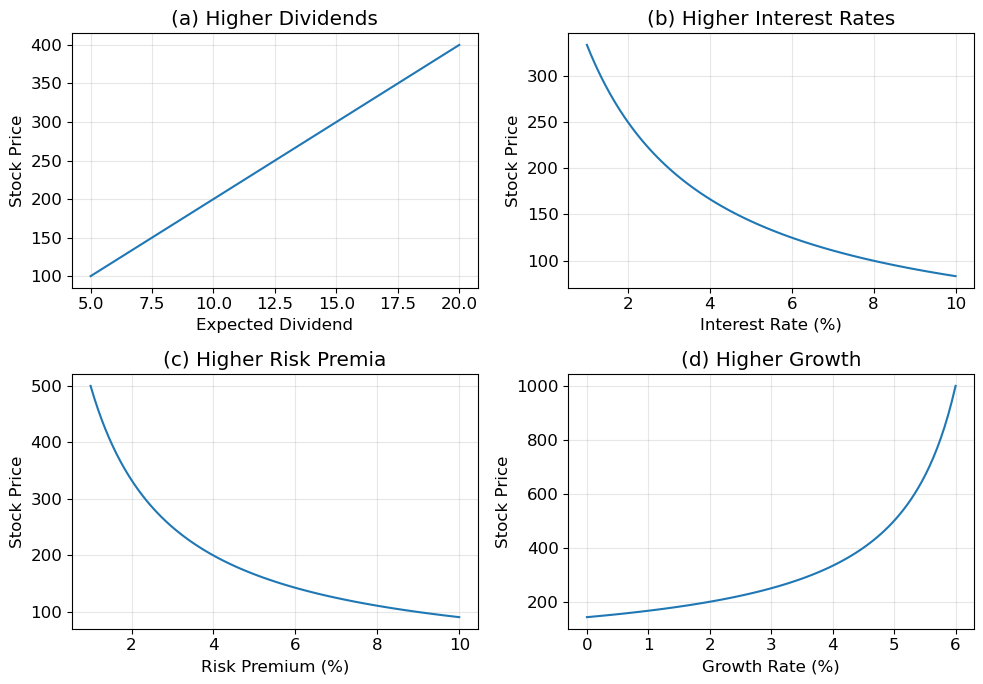

In [20]:
# You now change one variable at a time and keep the others fixed.
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

D_range = np.linspace(5, 20, 100)
V_D = D_range / (r_base + eps_base - g_base)
axes[0, 0].plot(D_range, V_D)
axes[0, 0].set_xlabel("Expected Dividend")
axes[0, 0].set_ylabel("Stock Price")
axes[0, 0].set_title("(a) Higher Dividends")

r_range = np.linspace(0.01, 0.10, 100)
V_r = D_base / (r_range + eps_base - g_base)
axes[0, 1].plot(r_range * 100, V_r)
axes[0, 1].set_xlabel("Interest Rate (%)")
axes[0, 1].set_ylabel("Stock Price")
axes[0, 1].set_title("(b) Higher Interest Rates")

eps_range = np.linspace(0.01, 0.10, 100)
V_eps = D_base / (r_base + eps_range - g_base)
axes[1, 0].plot(eps_range * 100, V_eps)
axes[1, 0].set_xlabel("Risk Premium (%)")
axes[1, 0].set_ylabel("Stock Price")
axes[1, 0].set_title("(c) Higher Risk Premia")

g_range = np.linspace(0.0, 0.06, 100)
valid = (r_base + eps_base - g_range) > 0.005
V_g = np.where(valid, D_base / (r_base + eps_base - g_range), np.nan)
axes[1, 1].plot(g_range[valid] * 100, V_g[valid])
axes[1, 1].set_xlabel("Growth Rate (%)")
axes[1, 1].set_ylabel("Stock Price")
axes[1, 1].set_title("(d) Higher Growth")

for ax in axes.flat:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4. Forward Iteration and Convergence

The Gordon formula is the closed-form version of an infinite discounted sum.


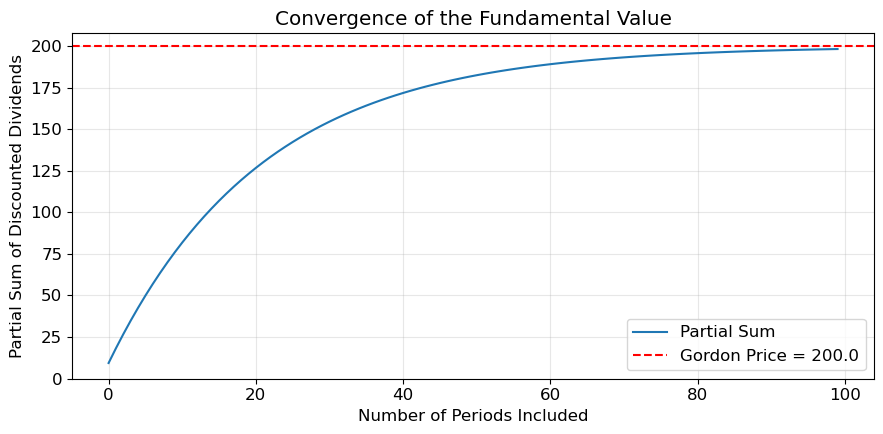

In [25]:
# You compare the closed-form Gordon price with a finite sum of dividends.
D0 = 10
r_eps = 0.07
g = 0.02
N_max = 100

V_true = D0 / (r_eps - g)
partial_sums = np.zeros(N_max)
cumulative = 0.0

for n in range(N_max):
    # You add one more discounted dividend in each step.
    cumulative = cumulative + D0 * (1 + g) ** n / (1 + r_eps) ** (n + 1)
    partial_sums[n] = cumulative

fig, ax = plt.subplots()
ax.plot(range(N_max), partial_sums, label="Partial Sum")
ax.axhline(V_true, color="red", ls="--", label=f"Gordon Price = {V_true:.1f}")
ax.set_xlabel("Number of Periods Included")
ax.set_ylabel("Partial Sum of Discounted Dividends")
ax.set_title("Convergence of the Fundamental Value")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- The figure shows that the **finite sum of discounted dividends converges to the Gordon price**.
- As more future dividends are included, the partial sum gets closer to the asset’s **fundamental value**.
- This illustrates that the Gordon formula is the **closed-form value of an infinite dividend stream**, provided `r_eps > g`.

## Notebook Part 3: Tobin's $q$ and the Optimal Level of Investment

This section matches the slides on **Tobin's $q$** and the **Figure 15.5: The Optimal Level of Investment**.

Recall the two key equations from the lecture:

$$q_t \equiv \frac{V_t^a}{K_t^a} \qquad \text{(definition of Tobin's } q\text{)}$$

$$q_t = 1 + c'(I_t) \qquad \text{(optimal investment rule)}$$

With quadratic adjustment costs $c(I_t) = \frac{a}{2} I_t^2$, so $c'(I_t) = a I_t$, the rule becomes:

$$q_t = 1 + a I_t \quad \Longleftrightarrow \quad I_t = \frac{q_t - 1}{a}$$

The firm invests more when $q_t$ is high (capital is valued highly by markets) and less when adjustment costs are steep (high $a$).

### 5a. Numerical Exercise: Compute Optimal Investment

Fill in the formula and compute $I_t^* = (q_t - 1)/a$ for a few combinations.

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# You fix the adjustment cost parameter and ask what investment the firm chooses.
a = 2.0   # adjustment cost parameter

# You compute optimal investment for different values of q.
q_values = [0.8, 1.0, 1.5, 2.0, 2.5]

print(f"Adjustment cost parameter a = {a}")
print(f"{'q_t':>6}  {'I_t* = (q-1)/a':>18}  {'Interpretation':>30}")
print("-" * 60)
for q in q_values:
    I_star = (q - 1) / a
    if q > 1:
        label = "invest (q > 1)"
    elif q == 1:
        label = "no net investment (q = 1)"
    else:
        label = "disinvest (q < 1)"
    print(f"{q:>6.2f}  {I_star:>18.3f}  {label:>30}")

Adjustment cost parameter a = 2.0
   q_t      I_t* = (q-1)/a                  Interpretation
------------------------------------------------------------
  0.80              -0.100               disinvest (q < 1)
  1.00               0.000       no net investment (q = 1)
  1.50               0.250                  invest (q > 1)
  2.00               0.500                  invest (q > 1)
  2.50               0.750                  invest (q > 1)


### 5b. Figure: The Optimal Level of Investment

This reproduces the logic of **Figure 15.5** from the book.

The upward-sloping curve $1 + aI_t$ is the marginal cost of investing. The horizontal line is $q_t$. 
The intersection pins down the optimal $I_t^*$.

**Try changing `q` and `a` below** to see how the optimal investment level shifts:
- A higher `q` shifts the horizontal line up → higher $I^*$
- A higher `a` steepens the cost curve → lower $I^*$ for the same `q`

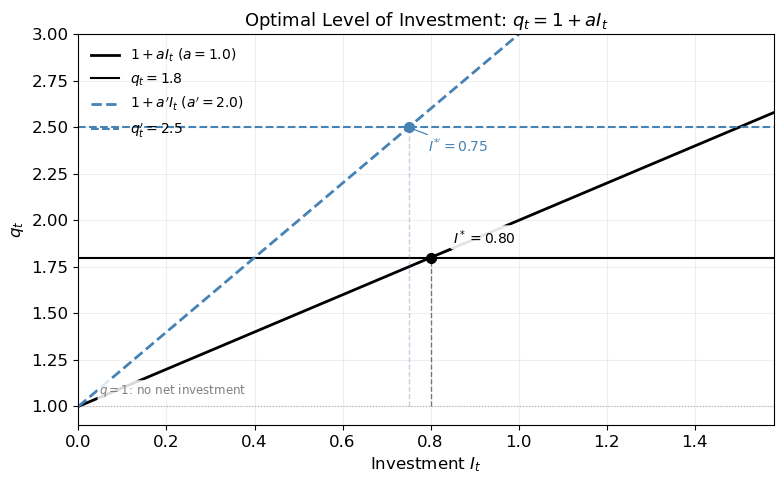

Scenario 1: q = 1.8,  a = 1.0  ->  I* = 0.800
Scenario 2: q = 2.5, a = 2.0 ->  I* = 0.750


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------
# Change these parameters to see what happens.
q   = 1.8   # Tobin's q (try: 1.2, 1.8, 2.5)
a   = 1.0   # adjustment cost parameter (try: 0.5, 1.0, 2.0)

q2  = 2.5   # second scenario: higher q
a2  = 2.0   # second scenario: steeper cost curve
# -------------------------------------------------------

I_star  = (q  - 1) / a
I_star2 = (q2 - 1) / a2

# x-axis runs just past the further intersection
x_max   = max(I_star, I_star2) * 1.6 + 0.3
I_range = np.linspace(0, x_max, 400)

mc1 = 1 + a  * I_range
mc2 = 1 + a2 * I_range

fig, ax = plt.subplots(figsize=(8, 5))

# Scenario 1
ax.plot(I_range, mc1, color="black", linewidth=2,
        label=fr"$1 + aI_t$ ($a = {a}$)")
ax.axhline(q, color="black", linewidth=1.5,
           label=fr"$q_t = {q}$")
ax.plot([I_star, I_star], [1, q], color="black",
        linewidth=1, linestyle="--", alpha=0.5)
ax.plot(I_star, q, "o", color="black", markersize=7, zorder=5)

# Scenario 2
ax.plot(I_range, mc2, color="steelblue", linewidth=2, linestyle="--",
        label=fr"$1 + a'I_t$ ($a' = {a2}$)")
ax.axhline(q2, color="steelblue", linewidth=1.5, linestyle="--",
           label=fr"$q_t' = {q2}$")
ax.plot([I_star2, I_star2], [1, q2], color="steelblue",
        linewidth=1, linestyle="--", alpha=0.35)
ax.plot(I_star2, q2, "o", color="steelblue", markersize=7, zorder=5)

# Annotation style: offset + white box
bbox_kw = dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9)
arrow_kw1 = dict(arrowstyle="-", color="black", lw=0.9, shrinkA=0, shrinkB=4)
arrow_kw2 = dict(arrowstyle="-", color="steelblue", lw=0.9, shrinkA=0, shrinkB=4)

ax.annotate(fr"$I^* = {I_star:.2f}$",
            xy=(I_star, q),
            xytext=(16, 10),
            textcoords="offset points",
            fontsize=10,
            color="black",
            bbox=bbox_kw,
            arrowprops=arrow_kw1)

ax.annotate(fr"$I^{{*'}} = {I_star2:.2f}$",
            xy=(I_star2, q2),
            xytext=(14, -18),
            textcoords="offset points",
            fontsize=10,
            color="steelblue",
            bbox=bbox_kw,
            arrowprops=arrow_kw2)

# Reference line at q = 1
ax.axhline(1, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)
ax.text(0.03 * x_max, 1.04, "$q = 1$: no net investment",
        fontsize=8.5, color="gray", va="bottom",
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85))

ax.set_xlabel("Investment $I_t$", fontsize=12)
ax.set_ylabel("$q_t$", fontsize=12)
ax.set_title("Optimal Level of Investment: $q_t = 1 + aI_t$", fontsize=13)
ax.set_xlim(0, x_max)
ax.set_ylim(0.9, max(q, q2) * 1.2)
ax.legend(fontsize=10, frameon=False, loc="upper left")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Scenario 1: q = {q},  a = {a}  ->  I* = {I_star:.3f}")
print(f"Scenario 2: q = {q2}, a = {a2} ->  I* = {I_star2:.3f}")


- **A higher Tobin's q increases investment.** Firms invest more when the market values installed capital more highly.
- **A higher adjustment cost parameter reduces investment.** Investment responds less when adjustment costs rise more steeply.
- **Optimal investment is determined where marginal benefit equals marginal cost**, that is, where `q_t = 1 + aI_t`.


### 5c. How Does Optimal Investment Respond to $q$ and $a$?

This panel shows $I^* = (q-1)/a$ as a function of $q$ for several values of $a$.
It makes the comparative statics from the lecture concrete.

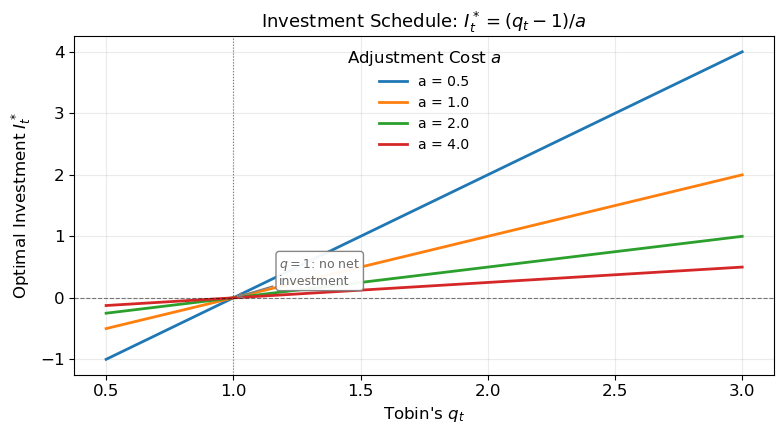

Key results:
  q < 1  ->  I* < 0  (disinvestment)
  q = 1  ->  I* = 0  (no net investment)
  q > 1  ->  I* > 0  (positive investment)
  Higher a -> flatter investment response to q


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# You plot optimal investment as a function of q for different cost parameters.
q_grid = np.linspace(0.5, 3.0, 200)

fig, ax = plt.subplots(figsize=(8, 4.5))

for a_val in [0.5, 1.0, 2.0, 4.0]:
    I_opt = (q_grid - 1) / a_val
    ax.plot(q_grid, I_opt, linewidth=2, label=f"a = {a_val}")

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axvline(1, color="black", linewidth=0.8, linestyle=":", alpha=0.5)

ax.annotate("$q = 1$: no net\ninvestment",
            xy=(1, 0),
            xytext=(1.18, 0.42),
            textcoords="data",
            fontsize=9,
            color="dimgray",
            ha="left",
            va="center",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.95),
            arrowprops=dict(arrowstyle="->", color="gray", lw=1.0))

ax.set_xlabel("Tobin's $q_t$", fontsize=12)
ax.set_ylabel("Optimal Investment $I_t^*$", fontsize=12)
ax.set_title("Investment Schedule: $I_t^* = (q_t - 1)/a$", fontsize=13)
ax.legend(title="Adjustment Cost $a$", fontsize=10, frameon=False)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# You print a short interpretation.
print("Key results:")
print("  q < 1  ->  I* < 0  (disinvestment)")
print("  q = 1  ->  I* = 0  (no net investment)")
print("  q > 1  ->  I* > 0  (positive investment)")
print("  Higher a -> flatter investment response to q")


- **Investment rises with Tobin's `q`.** When `q` increases, the firm's optimal investment increases.
- **`q = 1` is the no-net-investment threshold.** Below it, the firm disinvests; above it, the firm invests.
- **Higher adjustment costs flatten the investment schedule.** A larger `a` makes investment respond less to changes in `q`.

## Summary

This notebook:

1. Replicates the Denmark evidence from the slides.
2. Computes mean, standard deviation, and correlation.
3. Implements the main pricing equations in simple visual code.
4. Computes Tobin's $q$ and the optimal investment level with adjustment costs.
